# Task 1: Exploring and Visualizing the Iris Dataset

**Objective:** Load, inspect, and visualize the Iris dataset to understand data trends and distributions.

**Dataset:** Iris Dataset (loaded via seaborn)

**Skills Practiced:** pandas, seaborn, matplotlib, descriptive statistics

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set global plot style
sns.set_theme(style="darkgrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the Dataset

In [4]:
# Load Iris dataset via seaborn (no download needed)
iris = sns.load_dataset('iris')

print("Dataset loaded!")
print(f"Shape: {iris.shape}")
print(f"\nColumn Names: {iris.columns.tolist()}")
print(f"\nFirst 5 rows:")
iris.head()

Dataset loaded!
Shape: (150, 5)

Column Names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Dataset Summary Statistics

In [5]:
print("=== .info() ===")
iris.info()

=== .info() ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


In [6]:
print("\n=== .describe() ===")
iris.describe().round(2)


=== .describe() ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [7]:
print("\n=== Missing Values ===")
print(iris.isnull().sum())
print("\n=== Class Distribution ===")
print(iris['species'].value_counts())


=== Missing Values ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

=== Class Distribution ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 4. Data Visualization

### 4.1 Scatter Plot – Sepal Length vs Petal Length

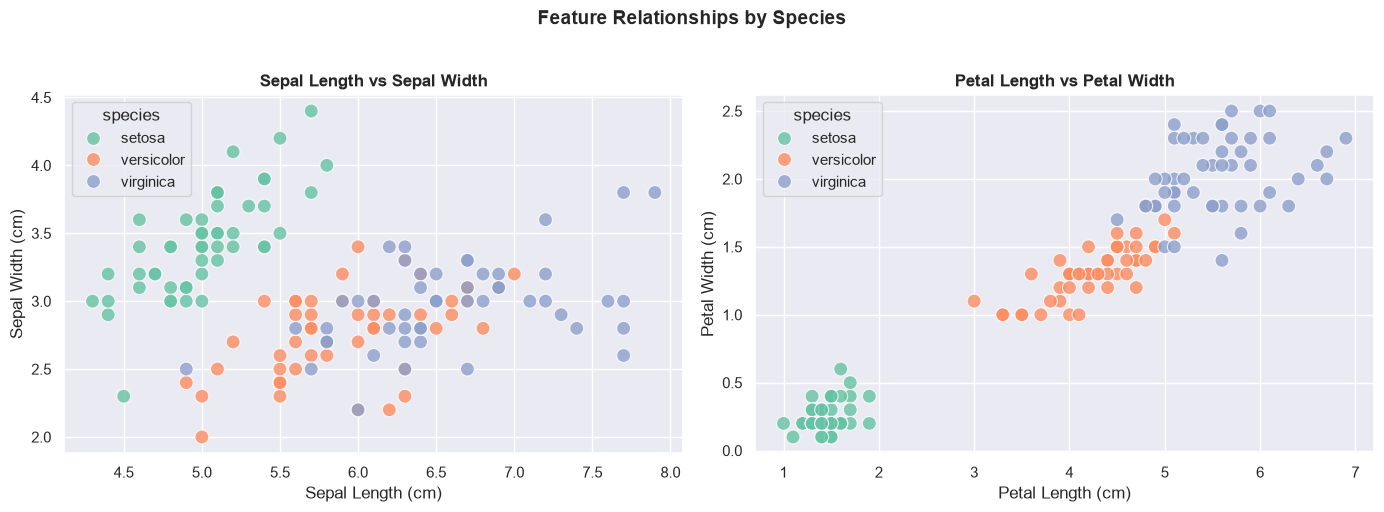

Scatter plots saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Sepal
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width',
                hue='species', s=100, alpha=0.8, ax=axes[0])
axes[0].set_title('Sepal Length vs Sepal Width', fontweight='bold')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')

# Scatter: Petal
sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='species', s=100, alpha=0.8, ax=axes[1])
axes[1].set_title('Petal Length vs Petal Width', fontweight='bold')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')

plt.suptitle('Feature Relationships by Species', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plots saved.")

### 4.2 Histograms – Feature Value Distributions

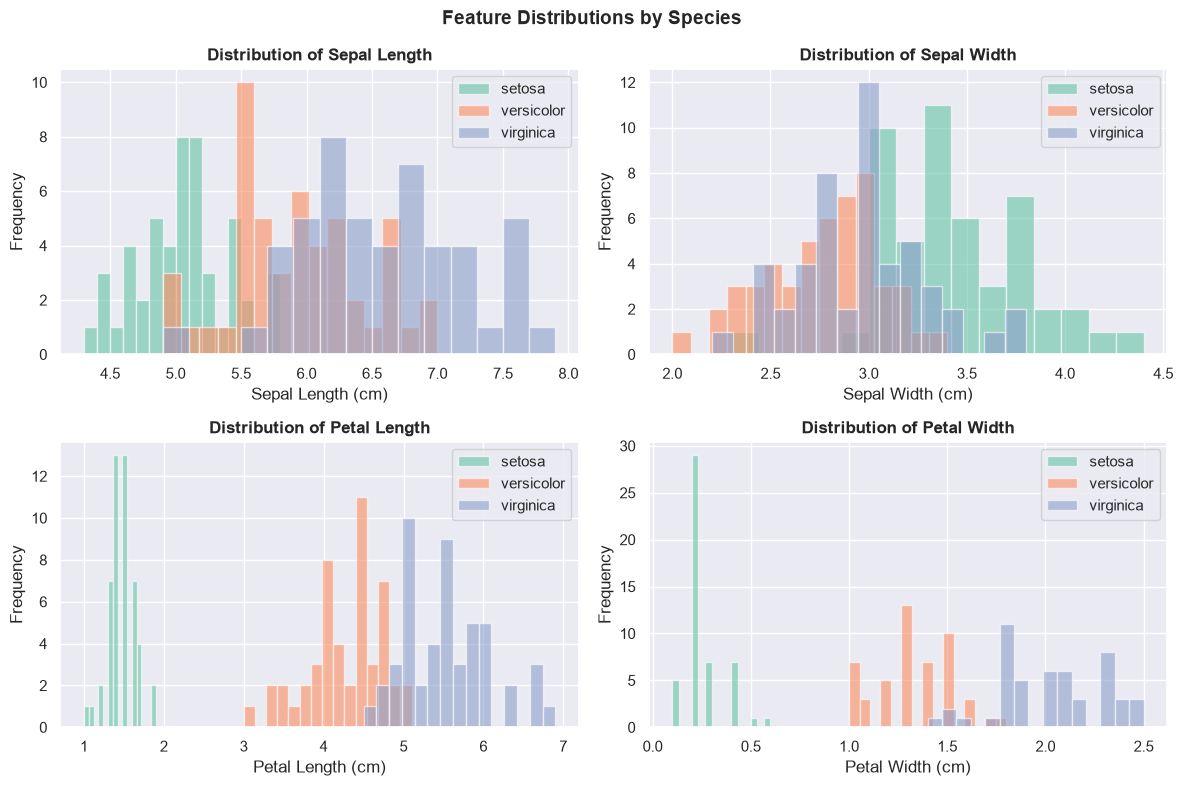

Histograms saved.


In [9]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for species in iris['species'].unique():
        subset = iris[iris['species'] == species][feat]
        axes[i].hist(subset, bins=15, alpha=0.6, label=species, edgecolor='white')
    axes[i].set_title(f'Distribution of {feat.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_xlabel(feat.replace("_", " ").title() + " (cm)")
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Feature Distributions by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Histograms saved.")

### 4.3 Box Plots – Identifying Outliers

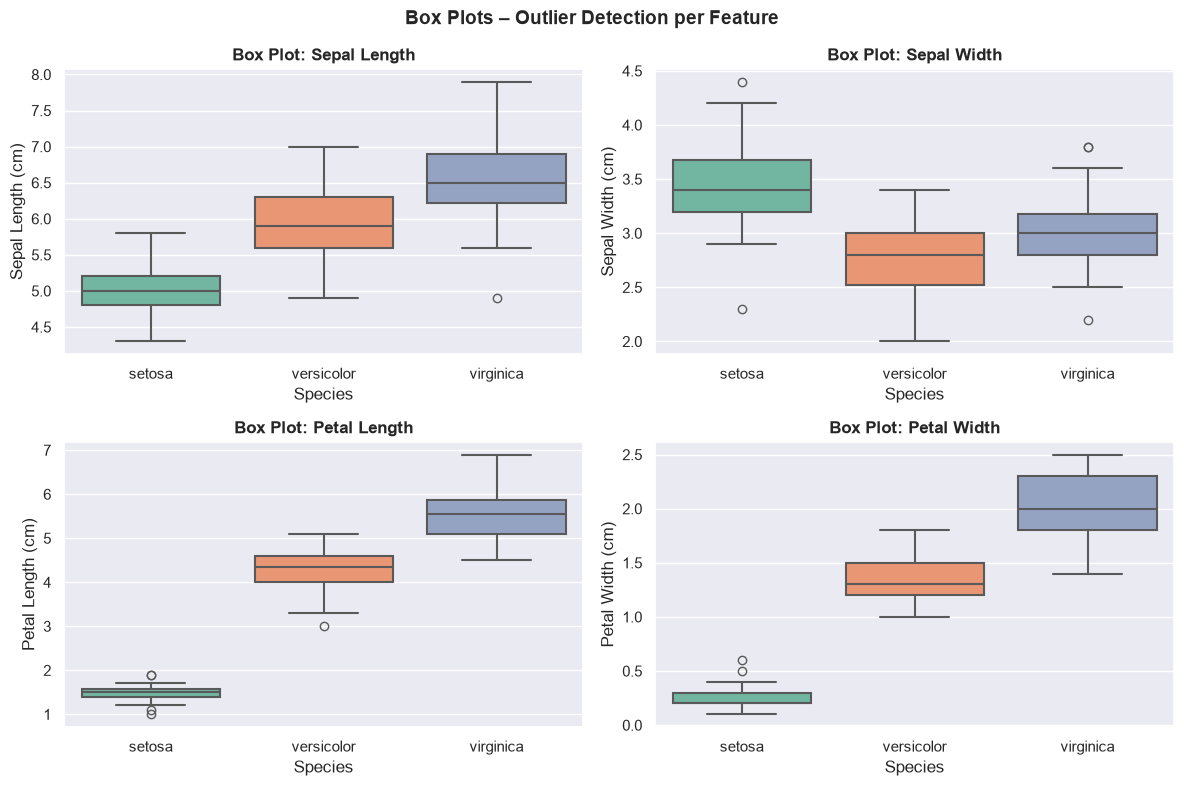

Box plots saved.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=iris, x='species', y=feat, palette='Set2',
                linewidth=1.5, ax=axes[i])
    axes[i].set_title(f'Box Plot: {feat.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(feat.replace("_", " ").title() + " (cm)")

plt.suptitle('Box Plots – Outlier Detection per Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Box plots saved.")

### 4.4 Pair Plot – All Feature Combinations

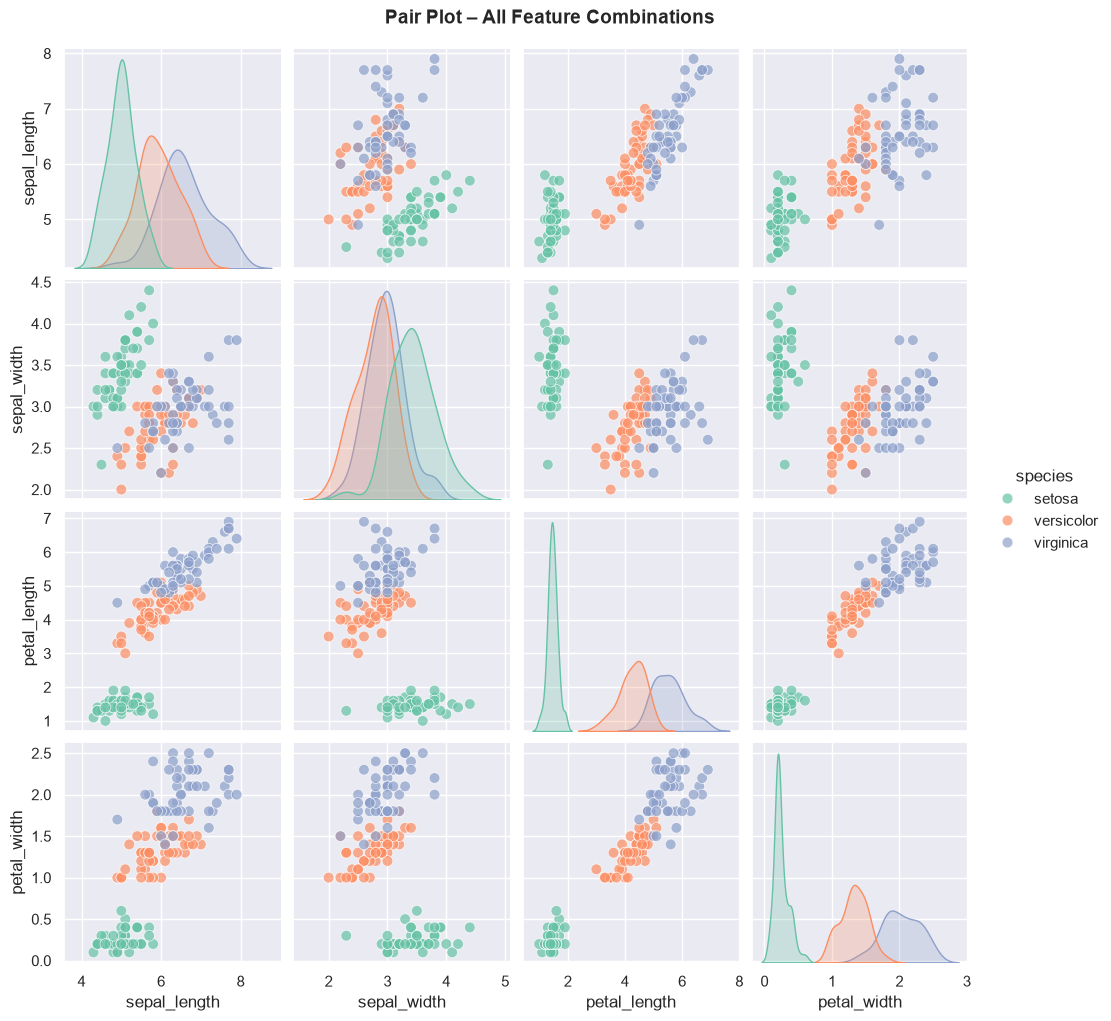

Pair plot saved.


In [11]:
pair = sns.pairplot(iris, hue='species', diag_kind='kde',
                    plot_kws={'alpha': 0.7, 's': 60}, height=2.5)
pair.fig.suptitle('Pair Plot – All Feature Combinations', y=1.02,
                  fontsize=14, fontweight='bold')
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Pair plot saved.")

### 4.5 Correlation Heatmap

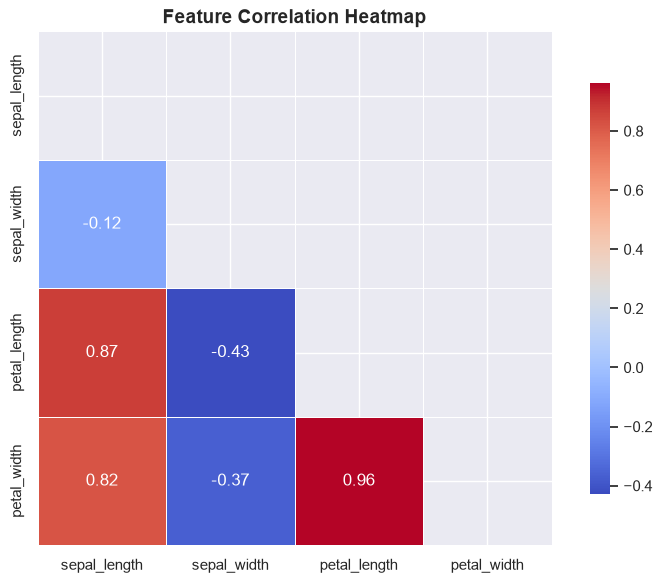

Heatmap saved.


In [12]:
plt.figure(figsize=(8, 6))
corr = iris.drop('species', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved.")

## 5. Key Insights & Findings

- **Petal features** (length & width) are the most discriminative — they separate species almost perfectly.
- **Setosa** is linearly separable from the other two species in petal dimensions.
- **Versicolor and Virginica** overlap slightly in sepal measurements but remain distinct in petal dimensions.
- **Strong correlation (0.96)** between petal length and petal width confirms they carry similar information.
- **No missing values** were found — the dataset is clean and ready for modeling.
- Box plots reveal a few mild outliers in sepal width for the Setosa class, but nothing severe.